# RQ2: Home Repeatability in Stroke Participants Only

**Research Question 2:** After identifying valid IMU-derived features in the laboratory, can the same feature set be extracted consistently from repeated unsupervised smartphone recordings in the home environment?

This notebook evaluates repeated home recordings for **stroke participants only**. A home row is included only if its `patient_id` maps to an `SRS...` participant in `subjects.json`. Unmapped home patients are excluded.

In [1]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 3)
warnings.filterwarnings("ignore", category=RuntimeWarning)

PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "Sensors_Visualizers" else Path.cwd()
SUBJECTS_JSON = PROJECT_ROOT / "subjects.json"
FEATURE_ROOT = PROJECT_ROOT

MIN_RECORDINGS_PER_SUBJECT = 3

PRIMARY_FEATURES = {
    "walk": ["walk_duration", "step_count", "cadence", "mean_step_time"],
    "left_turn": ["left_turn_duration", "left_turn_step_count", "left_turn_peak_angular_velocity"],
    "right_turn": ["right_turn_duration", "right_turn_step_count", "right_turn_peak_angular_velocity"],
    "sit_to_stand": ["sit_to_stand_duration", "sit_to_stand_time_to_peak_acc", "sit_to_stand_peak_acc", "sit_to_stand_peak_gyro"],
    "stand_to_sit": ["stand_to_sit_duration", "stand_to_sit_time_to_peak_acc", "stand_to_sit_peak_acc", "stand_to_sit_peak_gyro"],
}

FEATURE_LABELS = {
    "walk_duration": "Walk duration (s)",
    "step_count": "Walking step count",
    "cadence": "Walking cadence (steps/min)",
    "mean_step_time": "Walking mean step time (s)",
    "left_turn_duration": "Left turn duration (s)",
    "left_turn_step_count": "Left turn step count",
    "left_turn_peak_angular_velocity": "Left turn peak angular velocity",
    "right_turn_duration": "Right turn duration (s)",
    "right_turn_step_count": "Right turn step count",
    "right_turn_peak_angular_velocity": "Right turn peak angular velocity",
    "sit_to_stand_duration": "Sit-to-stand duration (s)",
    "sit_to_stand_time_to_peak_acc": "Sit-to-stand time to peak acc (s)",
    "sit_to_stand_peak_acc": "Sit-to-stand peak acc",
    "sit_to_stand_peak_gyro": "Sit-to-stand peak gyro",
    "stand_to_sit_duration": "Stand-to-sit duration (s)",
    "stand_to_sit_time_to_peak_acc": "Stand-to-sit time to peak acc (s)",
    "stand_to_sit_peak_acc": "Stand-to-sit peak acc",
    "stand_to_sit_peak_gyro": "Stand-to-sit peak gyro",
}

all_features = [f for group in PRIMARY_FEATURES.values() for f in group]
print("Project root:", PROJECT_ROOT)

Project root: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel


## Load Home Features and Keep SRS Stroke Participants Only

Rows are included only when `patient_id` maps through `subjects.json` to an `SRS...` participant. This excludes unmapped home patients from the RQ2 analysis.

In [2]:
def load_subject_map(path=SUBJECTS_JSON):
    with open(path, "r") as f:
        srs_to_patient = json.load(f)
    patient_to_srs = {f"patient_{patient_id}": srs_id for srs_id, patient_id in srs_to_patient.items()}
    return srs_to_patient, patient_to_srs


def load_home_features(root=FEATURE_ROOT):
    frames = []
    skipped = []
    for path in sorted(root.glob("features_dataset_*.csv")):
        try:
            df = pd.read_csv(path)
        except Exception as exc:
            skipped.append({"file": path.name, "reason": str(exc)})
            continue
        if df.empty:
            skipped.append({"file": path.name, "reason": "empty"})
            continue
        df = df.copy()
        df["source_file"] = path.name
        frames.append(df)
    return (pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()), pd.DataFrame(skipped)

srs_to_patient, patient_to_srs = load_subject_map()
home_raw, skipped_files = load_home_features()

home_all = home_raw.copy()
home_all["patient_id"] = home_all["patient_id"].astype(str)
home_all["subject_id"] = home_all["patient_id"].map(patient_to_srs)
home_all["date"] = pd.to_datetime(home_all["date"], errors="coerce")

excluded_unmapped = home_all[home_all["subject_id"].isna()].copy()
home = home_all[home_all["subject_id"].notna() & home_all["subject_id"].astype(str).str.startswith("SRS")].copy()
home = home.sort_values(["subject_id", "date"]).reset_index(drop=True)

print(f"Total loaded rows: {len(home_all):,}")
print(f"SRS stroke rows retained: {len(home):,}")
print(f"Unmapped/non-SRS rows excluded: {len(excluded_unmapped):,}")
print(f"SRS participants retained: {home['subject_id'].nunique()}")

display(skipped_files)
display(excluded_unmapped[["patient_id", "date", "source_file"]].drop_duplicates().head(20))
display(home[["subject_id", "patient_id", "date", "source_file"]].head())

Total loaded rows: 510
SRS stroke rows retained: 498
Unmapped/non-SRS rows excluded: 12
SRS participants retained: 17


,file,reason
0,features_dataset_12.csv,No columns to parse from file
1,features_dataset_72.csv,No columns to parse from file
2,features_dataset_78.csv,No columns to parse from file
3,features_dataset_81.csv,No columns to parse from file
4,features_dataset_96.csv,No columns to parse from file
5,features_dataset_97.csv,No columns to parse from file


,patient_id,date,source_file
38,patient_103,2026-03-03,features_dataset_103.csv
39,patient_103,2026-03-08,features_dataset_103.csv
40,patient_103,2026-03-16,features_dataset_103.csv
41,patient_103,2026-03-26,features_dataset_103.csv
42,patient_103,2026-03-30,features_dataset_103.csv
67,patient_111,2026-04-27,features_dataset_111.csv
68,patient_111,2026-04-28,features_dataset_111.csv
69,patient_111,2026-04-29,features_dataset_111.csv
70,patient_111,2026-04-30,features_dataset_111.csv
71,patient_111,2026-05-05,features_dataset_111.csv


,subject_id,patient_id,date,source_file
0,SRS001,patient_99,2025-12-06,features_dataset_99.csv
1,SRS001,patient_99,2025-12-07,features_dataset_99.csv
2,SRS001,patient_99,2025-12-08,features_dataset_99.csv
3,SRS001,patient_99,2025-12-09,features_dataset_99.csv
4,SRS001,patient_99,2025-12-10,features_dataset_99.csv


## Home Recording Summary

,srs_subjects,home_recordings,median_recordings_per_subject,min_recordings_per_subject,max_recordings_per_subject
0,17,498,18.0,1,232


,subject_id,n_recordings,n_days,followup_days
5,SRS05,232,232,363
7,SRS09,65,65,222
6,SRS08,30,30,62
12,SRS15,25,25,29
3,SRS03,24,24,29
14,SRS17,23,23,29
1,SRS002,23,23,37
4,SRS04,19,19,29
8,SRS11,18,18,27
0,SRS001,17,17,16


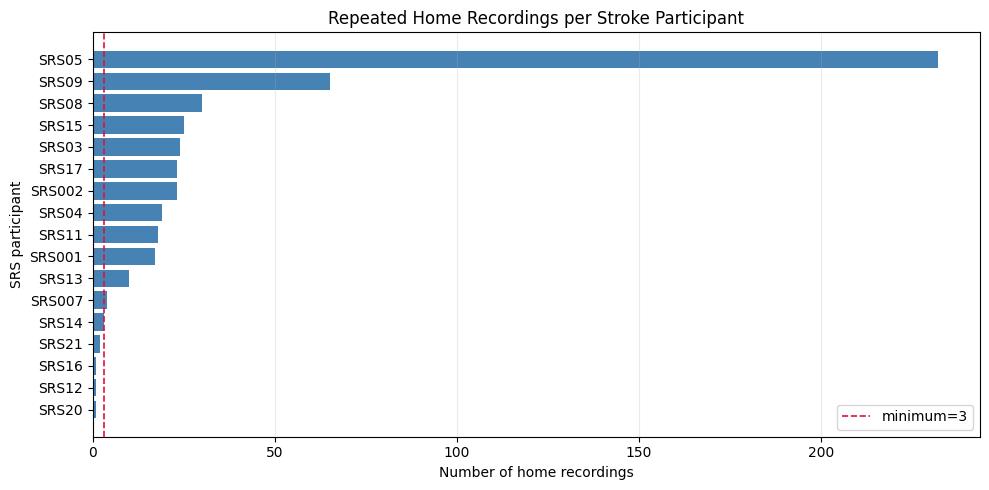

In [3]:
recording_counts = (
    home.groupby(["subject_id", "patient_id"], as_index=False)
    .agg(n_recordings=("date", "count"), first_date=("date", "min"), last_date=("date", "max"), n_days=("date", "nunique"))
    .sort_values("n_recordings", ascending=False)
)
recording_counts["followup_days"] = (recording_counts["last_date"] - recording_counts["first_date"]).dt.days

summary_counts = pd.DataFrame([{
    "srs_subjects": home["subject_id"].nunique(),
    "home_recordings": len(home),
    "median_recordings_per_subject": recording_counts["n_recordings"].median(),
    "min_recordings_per_subject": recording_counts["n_recordings"].min(),
    "max_recordings_per_subject": recording_counts["n_recordings"].max(),
}])
display(summary_counts)
display(recording_counts[["subject_id", "n_recordings", "n_days", "followup_days"]].head(10))

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = recording_counts.sort_values("n_recordings", ascending=True)
ax.barh(plot_df["subject_id"], plot_df["n_recordings"], color="steelblue")
ax.axvline(MIN_RECORDINGS_PER_SUBJECT, color="crimson", linestyle="--", linewidth=1.2, label=f"minimum={MIN_RECORDINGS_PER_SUBJECT}")
ax.set_xlabel("Number of home recordings")
ax.set_ylabel("SRS participant")
ax.set_title("Repeated Home Recordings per Stroke Participant")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Long-Format Feature Table

In [4]:
rows = []
for activity, features in PRIMARY_FEATURES.items():
    for feature in features:
        if feature not in home.columns:
            continue
        rows.append(pd.DataFrame({
            "subject_id": home["subject_id"],
            "patient_id": home["patient_id"],
            "date": home["date"],
            "activity": activity,
            "feature": feature,
            "feature_label": FEATURE_LABELS.get(feature, feature),
            "value": pd.to_numeric(home[feature], errors="coerce"),
        }))

home_long = pd.concat(rows, ignore_index=True).dropna(subset=["value", "date"])
print("Long feature rows:", len(home_long))
display(home_long.head())

Long feature rows: 8773


,subject_id,patient_id,date,activity,feature,feature_label,value
0,SRS001,patient_99,2025-12-06,walk,walk_duration,Walk duration (s),30.0
1,SRS001,patient_99,2025-12-07,walk,walk_duration,Walk duration (s),27.0
2,SRS001,patient_99,2025-12-08,walk,walk_duration,Walk duration (s),29.0
3,SRS001,patient_99,2025-12-09,walk,walk_duration,Walk duration (s),30.0
4,SRS001,patient_99,2025-12-10,walk,walk_duration,Walk duration (s),28.0


## Feature Availability

In [5]:
availability = (
    home_long.groupby(["activity", "feature", "feature_label"], as_index=False)
    .agg(available_n=("value", "count"), n_subjects=("subject_id", "nunique"))
)
availability["available_percent_of_rows"] = (availability["available_n"] / len(home) * 100).round(1)
availability = availability.sort_values("available_percent_of_rows", ascending=False)
display(availability[["activity", "feature_label", "n_subjects", "available_n", "available_percent_of_rows"]])

,activity,feature_label,n_subjects,available_n,available_percent_of_rows
0,left_turn,Left turn duration (s),16,491,98.6
2,left_turn,Left turn step count,16,491,98.6
13,stand_to_sit,Stand-to-sit time to peak acc (s),17,491,98.6
12,stand_to_sit,Stand-to-sit peak gyro,17,491,98.6
11,stand_to_sit,Stand-to-sit peak acc,17,491,98.6
10,stand_to_sit,Stand-to-sit duration (s),17,491,98.6
1,left_turn,Left turn peak angular velocity,16,491,98.6
8,sit_to_stand,Sit-to-stand peak gyro,17,487,97.8
9,sit_to_stand,Sit-to-stand time to peak acc (s),17,487,97.8
7,sit_to_stand,Sit-to-stand peak acc,17,487,97.8


## Repeatability Metrics

Repeatability is assessed without Vicon because home recordings have no Vicon reference.

- **Median CV%**: typical within-participant variability. Lower is better.
- **Repeatability ratio**: between-participant variance divided by total variance. Higher means participants remain distinguishable across repeated home recordings.
- **Median absolute day-to-day change**: typical absolute change between consecutive valid recordings.

In [6]:
def repeatability_ratio(values, subjects):
    data = pd.DataFrame({"value": values, "subject": subjects}).dropna()
    if data["subject"].nunique() < 2 or len(data) < 3:
        return np.nan, np.nan, np.nan
    subject_means = data.groupby("subject")["value"].mean()
    between_var = float(subject_means.var(ddof=1))
    within_vars = data.groupby("subject")["value"].var(ddof=1).dropna()
    within_var = float(within_vars.mean()) if len(within_vars) else np.nan
    total = between_var + within_var if np.isfinite(within_var) else np.nan
    ratio = between_var / total if np.isfinite(total) and total > 0 else np.nan
    return ratio, math.sqrt(within_var) if np.isfinite(within_var) else np.nan, math.sqrt(between_var) if np.isfinite(between_var) else np.nan

summary_rows = []
for (activity, feature, label), g in home_long.groupby(["activity", "feature", "feature_label"]):
    counts = g.groupby("subject_id")["value"].count()
    keep = counts[counts >= MIN_RECORDINGS_PER_SUBJECT].index
    g2 = g[g["subject_id"].isin(keep)].copy()
    if g2.empty:
        continue
    per_subject = g2.groupby("subject_id")["value"].agg(["count", "mean", "std"])
    per_subject["cv_percent"] = per_subject["std"] / per_subject["mean"].abs().replace(0, np.nan) * 100
    ratio, within_sd, between_sd = repeatability_ratio(g2["value"], g2["subject_id"])
    day_changes = []
    for _, sg in g2.sort_values("date").groupby("subject_id"):
        day_changes.extend(sg["value"].diff().abs().dropna().tolist())
    summary_rows.append({
        "activity": activity,
        "feature": feature,
        "feature_label": label,
        "n_subjects": int(g2["subject_id"].nunique()),
        "n_recordings": int(len(g2)),
        "mean_value": float(g2["value"].mean()),
        "sd_all_recordings": float(g2["value"].std(ddof=1)),
        "median_cv_percent": float(per_subject["cv_percent"].median()),
        "iqr_cv_percent": float(per_subject["cv_percent"].quantile(.75) - per_subject["cv_percent"].quantile(.25)),
        "within_subject_sd": within_sd,
        "between_subject_sd": between_sd,
        "repeatability_ratio": ratio,
        "median_abs_day_to_day_change": float(np.nanmedian(day_changes)) if day_changes else np.nan,
    })

repeatability_summary = pd.DataFrame(summary_rows)
for col in repeatability_summary.select_dtypes(include=[np.number]).columns:
    repeatability_summary[col] = repeatability_summary[col].round(3)
repeatability_summary = repeatability_summary.sort_values("repeatability_ratio", ascending=False)
display(repeatability_summary)

,activity,feature,feature_label,n_subjects,n_recordings,mean_value,sd_all_recordings,median_cv_percent,iqr_cv_percent,within_subject_sd,between_subject_sd,repeatability_ratio,median_abs_day_to_day_change
17,walk,walk_duration,Walk duration (s),13,480,22.269,7.700,23.752,8.182,4.539,7.031,0.706,3.000
5,right_turn,right_turn_step_count,Right turn step count,12,478,12.695,5.122,22.962,10.810,2.907,4.215,0.678,2.000
4,right_turn,right_turn_peak_angular_velocity,Right turn peak angular velocity,12,478,1.719,0.718,25.920,13.008,0.492,0.696,0.667,0.268
16,walk,step_count,Walking step count,13,480,24.290,9.043,23.907,7.651,5.812,8.167,0.664,5.000
3,right_turn,right_turn_duration,Right turn duration (s),12,478,8.179,2.315,17.218,15.454,1.509,1.925,0.619,0.880
1,left_turn,left_turn_peak_angular_velocity,Left turn peak angular velocity,13,487,1.746,0.775,34.043,35.748,0.557,0.678,0.597,0.229
2,left_turn,left_turn_step_count,Left turn step count,13,487,12.150,5.145,23.453,14.516,3.256,3.668,0.559,2.000
14,walk,cadence,Walking cadence (steps/min),13,480,71.569,31.495,22.328,11.033,21.817,22.197,0.509,16.468
0,left_turn,left_turn_duration,Left turn duration (s),13,487,7.997,2.475,21.511,16.813,1.714,1.746,0.509,0.892
12,stand_to_sit,stand_to_sit_peak_gyro,Stand-to-sit peak gyro,13,486,2.341,1.483,53.687,28.006,1.521,1.399,0.459,0.427


## RQ2 Interpretation Table

In [7]:
def interpret(row):
    ratio = row["repeatability_ratio"]
    cv = row["median_cv_percent"]
    if pd.isna(ratio) or row["n_subjects"] < 5:
        return "insufficient repeated SRS data"
    if ratio >= 0.75 and cv <= 25:
        return "strong home consistency"
    if ratio >= 0.50 and cv <= 35:
        return "moderate home consistency"
    if ratio >= 0.35:
        return "limited but usable with caution"
    return "weak home consistency"

rq2_table = repeatability_summary.copy()
rq2_table["interpretation"] = rq2_table.apply(interpret, axis=1)
rq2_table = rq2_table[["activity", "feature_label", "n_subjects", "n_recordings", "median_cv_percent", "within_subject_sd", "between_subject_sd", "repeatability_ratio", "median_abs_day_to_day_change", "interpretation"]]
display(rq2_table)

,activity,feature_label,n_subjects,n_recordings,median_cv_percent,within_subject_sd,between_subject_sd,repeatability_ratio,median_abs_day_to_day_change,interpretation
17,walk,Walk duration (s),13,480,23.752,4.539,7.031,0.706,3.000,moderate home consistency
5,right_turn,Right turn step count,12,478,22.962,2.907,4.215,0.678,2.000,moderate home consistency
4,right_turn,Right turn peak angular velocity,12,478,25.920,0.492,0.696,0.667,0.268,moderate home consistency
16,walk,Walking step count,13,480,23.907,5.812,8.167,0.664,5.000,moderate home consistency
3,right_turn,Right turn duration (s),12,478,17.218,1.509,1.925,0.619,0.880,moderate home consistency
1,left_turn,Left turn peak angular velocity,13,487,34.043,0.557,0.678,0.597,0.229,moderate home consistency
2,left_turn,Left turn step count,13,487,23.453,3.256,3.668,0.559,2.000,moderate home consistency
14,walk,Walking cadence (steps/min),13,480,22.328,21.817,22.197,0.509,16.468,moderate home consistency
0,left_turn,Left turn duration (s),13,487,21.511,1.714,1.746,0.509,0.892,moderate home consistency
12,stand_to_sit,Stand-to-sit peak gyro,13,486,53.687,1.521,1.399,0.459,0.427,limited but usable with caution


## Home Repeatability by Feature

Use this plot as the main visual answer for RQ2. Features are sorted from lower to higher home repeatability. The vertical lines mark weak/limited, moderate, and strong consistency zones.

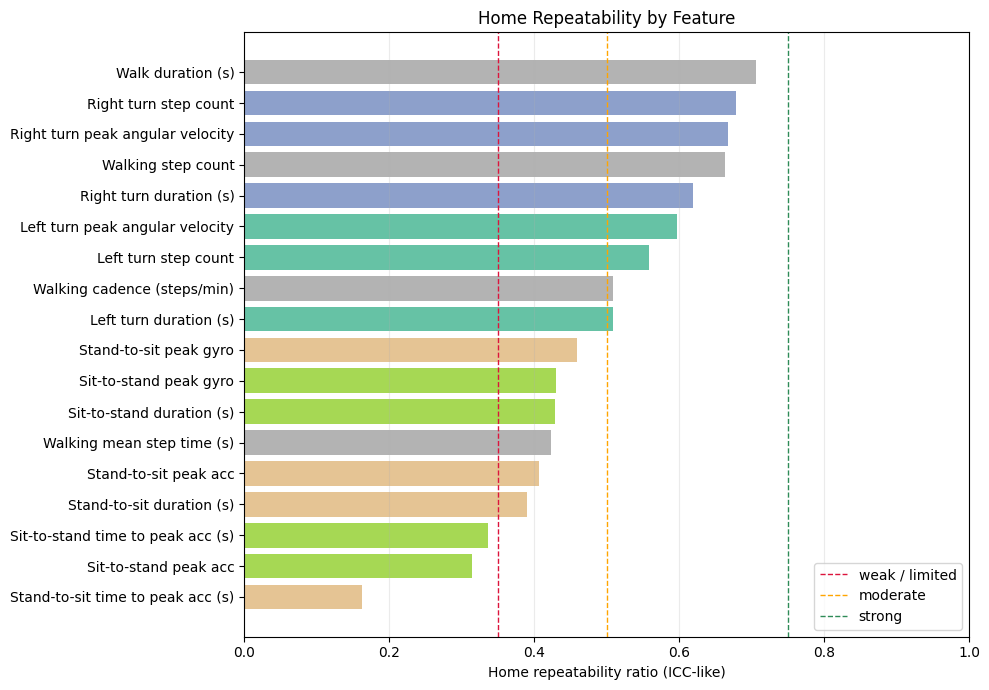

In [8]:
feature_plot = repeatability_summary.dropna(subset=["repeatability_ratio"]).copy()
feature_plot = feature_plot[feature_plot["n_subjects"] >= 2]
feature_plot = feature_plot.sort_values("repeatability_ratio", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
activity_codes = feature_plot["activity"].astype("category").cat.codes
colors = plt.cm.Set2(activity_codes / max(activity_codes.max(), 1))

ax.barh(feature_plot["feature_label"], feature_plot["repeatability_ratio"], color=colors)
ax.axvline(0.35, color="crimson", linestyle="--", linewidth=1, label="weak / limited")
ax.axvline(0.50, color="orange", linestyle="--", linewidth=1, label="moderate")
ax.axvline(0.75, color="seagreen", linestyle="--", linewidth=1, label="strong")
ax.set_xlabel("Home repeatability ratio (ICC-like)")
ax.set_title("Home Repeatability by Feature")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Final RQ2 Answer

In [9]:
final_summary = rq2_table.sort_values("repeatability_ratio", ascending=False)
compact_final = final_summary[[
    "activity", "feature_label", "n_subjects", "n_recordings", "median_cv_percent", "repeatability_ratio", "interpretation"
]].copy()
display(compact_final)

print("RQ2 short answer, SRS stroke participants only:")
moderate_or_better = compact_final[compact_final["interpretation"].isin(["strong home consistency", "moderate home consistency"])]
print("Features with moderate-or-better home consistency:")
print(", ".join(moderate_or_better["feature_label"].tolist()) if len(moderate_or_better) else "None")

,activity,feature_label,n_subjects,n_recordings,median_cv_percent,repeatability_ratio,interpretation
17,walk,Walk duration (s),13,480,23.752,0.706,moderate home consistency
5,right_turn,Right turn step count,12,478,22.962,0.678,moderate home consistency
4,right_turn,Right turn peak angular velocity,12,478,25.920,0.667,moderate home consistency
16,walk,Walking step count,13,480,23.907,0.664,moderate home consistency
3,right_turn,Right turn duration (s),12,478,17.218,0.619,moderate home consistency
1,left_turn,Left turn peak angular velocity,13,487,34.043,0.597,moderate home consistency
2,left_turn,Left turn step count,13,487,23.453,0.559,moderate home consistency
14,walk,Walking cadence (steps/min),13,480,22.328,0.509,moderate home consistency
0,left_turn,Left turn duration (s),13,487,21.511,0.509,moderate home consistency
12,stand_to_sit,Stand-to-sit peak gyro,13,486,53.687,0.459,limited but usable with caution


RQ2 short answer, SRS stroke participants only:
Features with moderate-or-better home consistency:
Walk duration (s), Right turn step count, Right turn peak angular velocity, Walking step count, Right turn duration (s), Left turn peak angular velocity, Left turn step count, Walking cadence (steps/min), Left turn duration (s)


## Subject-Level Boxplots

Use these boxplots as a secondary visual check. They show whether each SRS participant has a stable personal range for selected home features.

/var/folders/tc/lg28gc092b1b4y156tvz09v00000gn/T/ipykernel_10627/1306299704.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=order, showfliers=True)


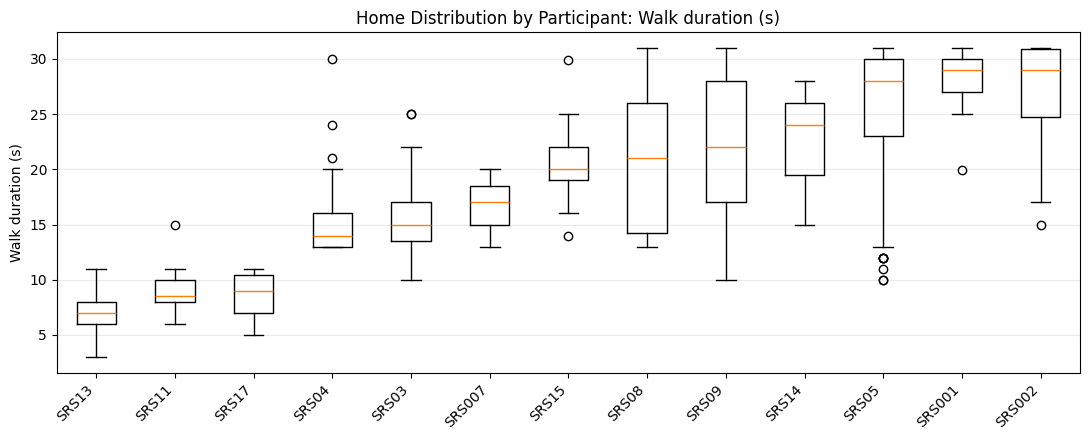

/var/folders/tc/lg28gc092b1b4y156tvz09v00000gn/T/ipykernel_10627/1306299704.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=order, showfliers=True)


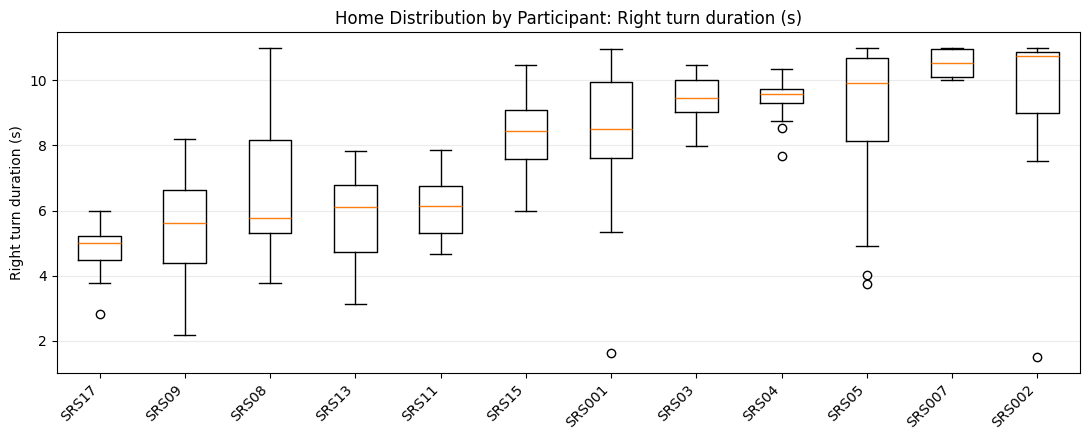

/var/folders/tc/lg28gc092b1b4y156tvz09v00000gn/T/ipykernel_10627/1306299704.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=order, showfliers=True)


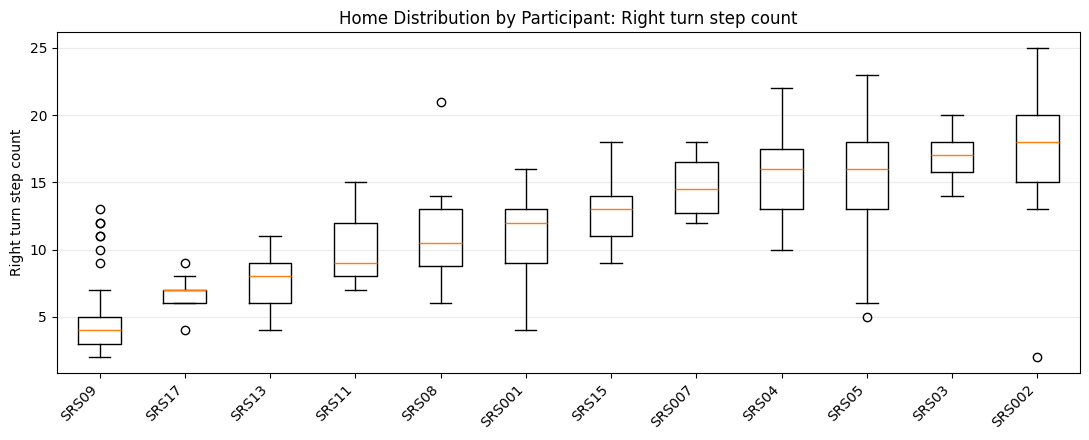

/var/folders/tc/lg28gc092b1b4y156tvz09v00000gn/T/ipykernel_10627/1306299704.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=order, showfliers=True)


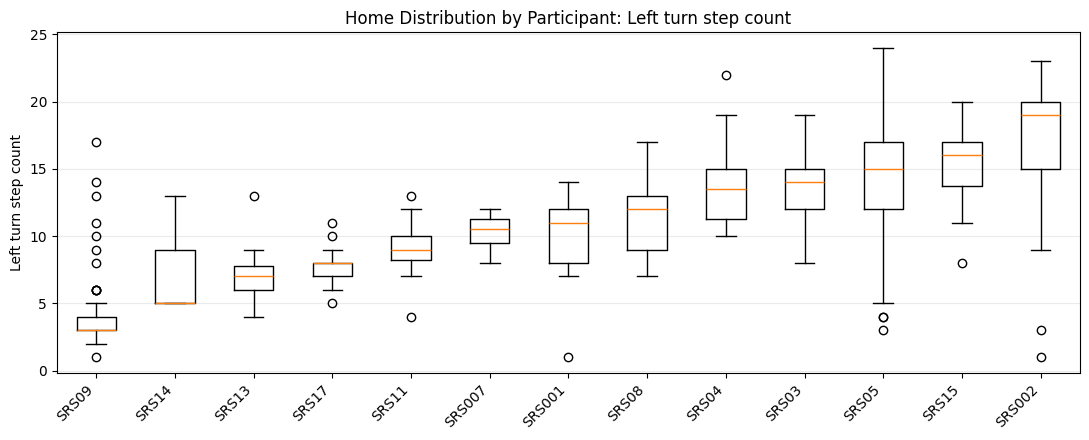

In [10]:
BOXPLOT_FEATURES = [
    "walk_duration",
    "right_turn_duration",
    "right_turn_step_count",
    "left_turn_step_count",
]

for feature in BOXPLOT_FEATURES:
    data = home_long[home_long["feature"].eq(feature)].copy()
    counts = data.groupby("subject_id")["value"].count()
    keep = counts[counts >= MIN_RECORDINGS_PER_SUBJECT].index
    data = data[data["subject_id"].isin(keep)]
    if data.empty:
        continue

    label = FEATURE_LABELS.get(feature, feature)
    order = data.groupby("subject_id")["value"].median().sort_values().index
    values = [data.loc[data["subject_id"].eq(subject), "value"].dropna().values for subject in order]

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.boxplot(values, labels=order, showfliers=True)
    ax.set_title(f"Home Distribution by Participant: {label}")
    ax.set_ylabel(label)
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()